Multi-Target Wholesale Price Forecasting with Explainable LightGBM

**Project:** AI-Powered Agricultural Procurement Decision Support System  
**Task:** Multi-Output Regression (Predicting Next Month's Prices)  
**Targets:** `Min_Price_next`, `Avg_Price_next`, `Max_Price_next`  
**Model:** `lightgbm.LGBMRegressor` inside `MultiOutputRegressor`

In [51]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

print(f" LightGBM Version: {lgb.__version__}")
print(f" SHAP Version: {shap.__version__}")

 LightGBM Version: 4.7.0
 SHAP Version: 0.49.1


In [61]:
# Data Ingestion & Next-Month Target Shifting
# Load Feature-Engineered Dataset directly from Step 04
data_path = os.path.join('data', 'all_months_features.csv')

if os.path.exists(data_path):
    df_raw = pd.read_csv(data_path)
    print(f"✓ Feature dataset loaded successfully from '{data_path}'. Shape: {df_raw.shape}")
else:
    raise FileNotFoundError(f"File not found at '{data_path}'. Please run step 04 first.")

# Sort chronologically by product and reassign continuous month index per product
df = df_raw.copy()
df['month_idx'] = df.groupby('Product_Name').cumcount() + 1
df = df.sort_values(by=['Product_Name', 'month_idx']).reset_index(drop=True)

# Create Next-Month Target Variables (t + 1)
targets_base = ['Min_Price', 'Avg_Price', 'Max_Price']
targets_next = ['Min_Price_next', 'Avg_Price_next', 'Max_Price_next']

for base_col, next_col in zip(targets_base, targets_next):
    df[next_col] = df.groupby('Product_Name')[base_col].shift(-1)

# Drop rows where target for next month is unavailable (e.g. last month per commodity)
df_clean = df.dropna(subset=targets_next).copy().reset_index(drop=True)
print(f"✓ Cleaned dataset for next-month forecasting shape: {df_clean.shape}")

✓ Feature dataset loaded successfully from 'data/all_months_features.csv'. Shape: (798, 77)
✓ Cleaned dataset for next-month forecasting shape: (641, 80)


In [62]:
# Feature & Target Matrices Separation
# Metadata and original base target columns to exclude from predictor features
non_feature_cols = [
    'Product_Name', 'Category', 'Unit', 'unit_canonical', 'month_name',
    'bs_year', 'bs_month'
] + targets_base + targets_next

feature_cols = [col for col in df_clean.columns if col not in non_feature_cols]

# Construct Feature Matrix (X) and Target Matrix (y)
X = df_clean[feature_cols].copy()
y = df_clean[targets_next].copy()

# Ensure strictly numeric float representation
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"✓ Predictor Features (X): {X.shape[1]} columns")
print(f"✓ Target Variables (y): {list(y.columns)}")

✓ Predictor Features (X): 67 columns
✓ Target Variables (y): ['Min_Price_next', 'Avg_Price_next', 'Max_Price_next']


In [63]:
# Temporal Split Across All Testing Months & Naive Baseline
# Chronological Train/Test Split
# Train Set: Months 1–8 | Test Set: All remaining out-of-sample months (Months 9 & 10)
train_mask = (df_clean['month_idx'] <= 8).values
test_mask = (df_clean['month_idx'] >= 9).values

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

# Naive Baseline: Predict Next Month Price (t+1) = Current Month Base Price (t)
y_baseline_df = df_clean.loc[test_mask, targets_base].copy()
y_baseline_df = y_baseline_df.fillna(method='ffill').fillna(0)
y_baseline = y_baseline_df.values

# Ensure target matrices are free of missing values
y_train = y_train.fillna(0)
y_test = y_test.fillna(0)

print(f"✓ Training Samples (Months 1–8): {X_train.shape[0]} rows")
print(f"✓ Testing Samples (Months 9–10): {X_test.shape[0]} rows")

✓ Training Samples (Months 1–8): 592 rows
✓ Testing Samples (Months 9–10): 49 rows


In [64]:
# LightGBM Multi-Target Model Training & Post-Processing
# Initialize Base LightGBM Regressor inside MultiOutputRegressor
lgb_base = lgb.LGBMRegressor(
    n_estimators=150,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

model = MultiOutputRegressor(lgb_base)
print("Training Multi-Output LightGBM Model...")
model.fit(X_train, y_train)

# Predict on Out-of-Sample Test Set
y_pred_arr = model.predict(X_test)
y_pred_df = pd.DataFrame(y_pred_arr, columns=targets_next)

# Apply Business Logic Constraint: Min_Price <= Avg_Price <= Max_Price
y_pred_df['Min_Price_next'] = np.minimum(y_pred_df['Min_Price_next'], y_pred_df['Avg_Price_next'])
y_pred_df['Max_Price_next'] = np.maximum(y_pred_df['Max_Price_next'], y_pred_df['Avg_Price_next'])
y_pred = y_pred_df.values

print("✓ Multi-Target LightGBM training and post-processing complete.")

Training Multi-Output LightGBM Model...
✓ Multi-Target LightGBM training and post-processing complete.


In [65]:
# Evaluation Metrics Across All Testing Months (NaN-Safe)
metrics = []

for i, col in enumerate(targets_next):
    y_true = y_test.iloc[:, i].values
    y_p = y_pred[:, i]
    y_b = y_baseline[:, i]

    # Filter out invalid or NaN pairs
    valid_mask = ~np.isnan(y_true) & ~np.isnan(y_b) & ~np.isnan(y_p)
    
    y_true_clean = y_true[valid_mask]
    y_p_clean = y_p[valid_mask]
    y_b_clean = y_b[valid_mask]

    # LightGBM Performance Metrics
    lgb_mae = mean_absolute_error(y_true_clean, y_p_clean)
    lgb_rmse = np.sqrt(mean_squared_error(y_true_clean, y_p_clean))
    lgb_r2 = r2_score(y_true_clean, y_p_clean)
    
    # Naive Baseline Performance Metrics
    base_mae = mean_absolute_error(y_true_clean, y_b_clean)
    base_rmse = np.sqrt(mean_squared_error(y_true_clean, y_b_clean))
    base_r2 = r2_score(y_true_clean, y_b_clean)
    
    metrics.append({
        'Target': col,
        'LGBM MAE': round(lgb_mae, 2),
        'Baseline MAE': round(base_mae, 2),
        'LGBM RMSE': round(lgb_rmse, 2),
        'Baseline RMSE': round(base_rmse, 2),
        'LGBM R2': round(lgb_r2, 4),
        'Baseline R2': round(base_r2, 4)
    })

df_metrics = pd.DataFrame(metrics)
print("\n=== OVERALL MODEL PERFORMANCE VS BASELINE (TEST SET) ===")
print(df_metrics.to_string(index=False))


=== OVERALL MODEL PERFORMANCE VS BASELINE (TEST SET) ===
        Target  LGBM MAE  Baseline MAE  LGBM RMSE  Baseline RMSE  LGBM R2  Baseline R2
Min_Price_next     30.19         27.04      63.21          64.31   0.6713       0.6597
Avg_Price_next     44.72         21.08      93.47          38.15   0.8565       0.9761
Max_Price_next     67.82         24.63     175.50          47.37  -0.6937       0.8766


In [66]:
# Month-by-Month Breakdown Comparison
test_df_eval = df_clean.loc[test_mask, ['Product_Name', 'month_idx']].copy().reset_index(drop=True)

for month in sorted(test_df_eval['month_idx'].unique()):
    m_mask = (test_df_eval['month_idx'] == month).values
    print(f"\n--- Metrics for month_idx = {month} ({m_mask.sum()} commodities) ---")
    
    m_metrics = []
    for i, col in enumerate(targets_next):
        y_t_m = y_test.iloc[m_mask, i].values
        y_p_m = y_pred[m_mask, i]
        y_b_m = y_baseline[m_mask, i]
        
        m_metrics.append({
            'Target': col,
            'LGBM MAE': round(mean_absolute_error(y_t_m, y_p_m), 2),
            'Baseline MAE': round(mean_absolute_error(y_t_m, y_b_m), 2),
            'LGBM RMSE': round(np.sqrt(mean_squared_error(y_t_m, y_p_m)), 2)
        })
    print(pd.DataFrame(m_metrics).to_string(index=False))


--- Metrics for month_idx = 9 (49 commodities) ---
        Target  LGBM MAE  Baseline MAE  LGBM RMSE
Min_Price_next     30.19         27.04      63.21
Avg_Price_next     44.72         21.08      93.47
Max_Price_next     67.82         24.63     175.50


In [68]:

# Ensure JS/interactive rendering works properly in Jupyter environments
shap.initjs()

# Define price targets and corresponding trained estimator mapping
target_names = ['Min_Price_next', 'Avg_Price_next', 'Max_Price_next']
target_labels = ['Min (Floor)', 'Avg (Centre)', 'Max (Ceiling)']

# Dictionary to store SHAP Explanation objects for each target
shap_explanations = {}

for name, est in zip(target_names, model.estimators_):
    explainer = shap.TreeExplainer(est)
    # Compute SHAP Explanation object on test features to prevent train overfit bias
    shap_explanations[name] = explainer(X_test)

print("✓ SHAP Explanations computed successfully for all 3 price targets.")

✓ SHAP Explanations computed successfully for all 3 price targets.


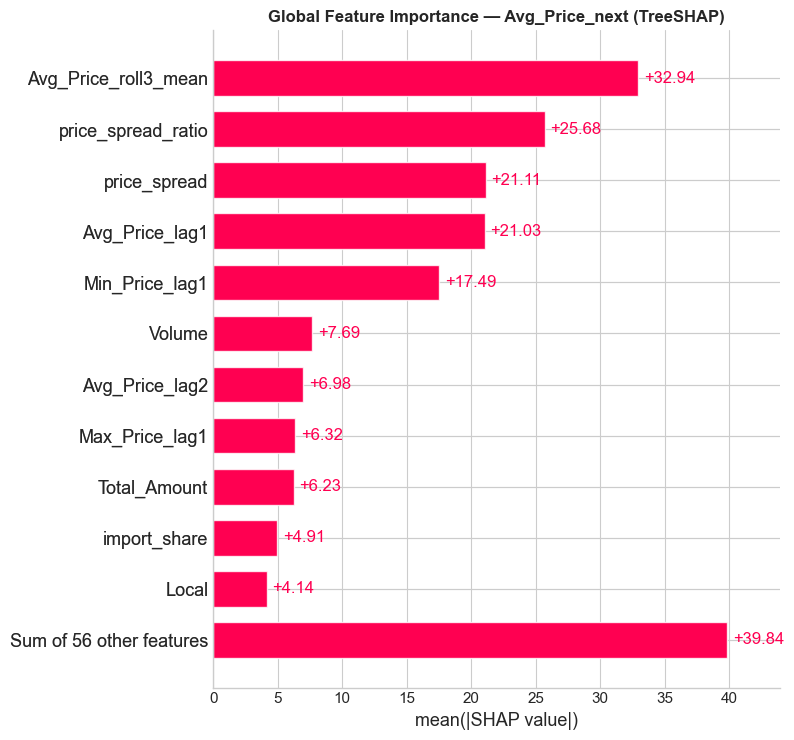

In [69]:
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_explanations['Avg_Price_next'], max_display=12, show=False)
plt.title("Global Feature Importance — Avg_Price_next (TreeSHAP)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

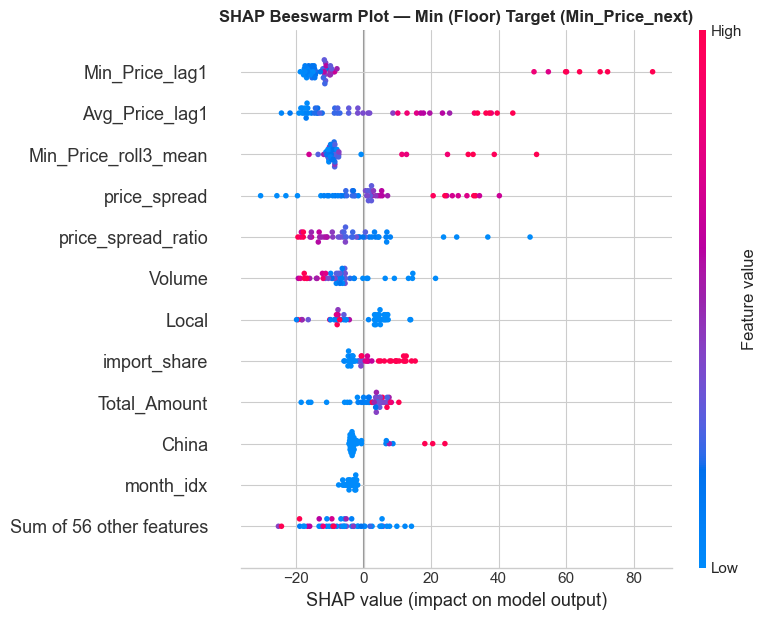

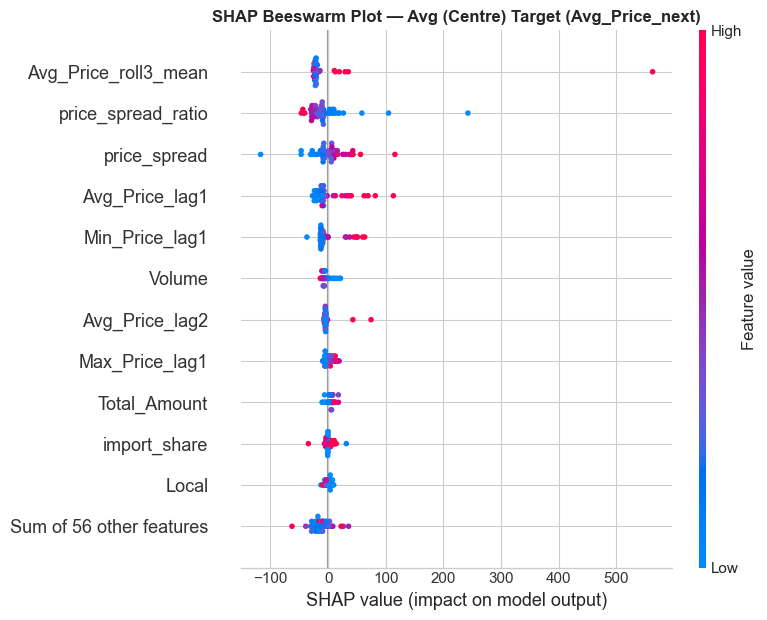

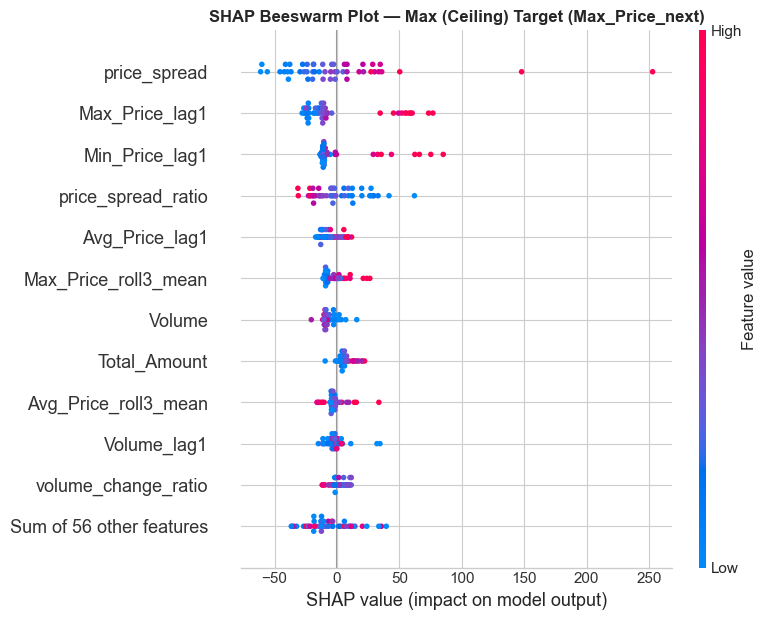

In [70]:
# Beeswarm Plots for ALL 3 Targets
for name, label in zip(target_names, target_labels):
    plt.figure(figsize=(10, 6))
    shap.plots.beeswarm(shap_explanations[name], max_display=12, show=False)
    plt.title(f"SHAP Beeswarm Plot — {label} Target ({name})", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

<Figure size 900x500 with 0 Axes>

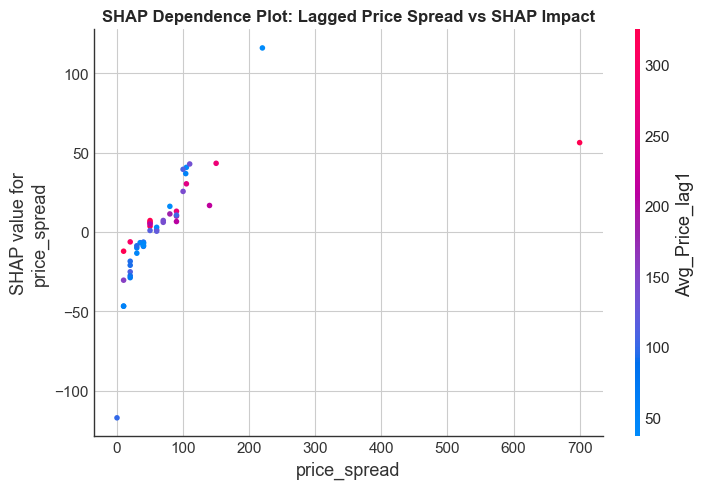

In [71]:
#  SHAP Dependence Plot (price_spread vs Avg_Price_next)

plt.figure(figsize=(9, 5))
# Plots feature value of price_spread against its SHAP value, colored by Avg_Price_lag1
shap.dependence_plot(
    "price_spread", 
    shap_explanations['Avg_Price_next'].values, 
    X_test, 
    interaction_index="Avg_Price_lag1",
    show=False
)
plt.title("SHAP Dependence Plot: Lagged Price Spread vs SHAP Impact", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

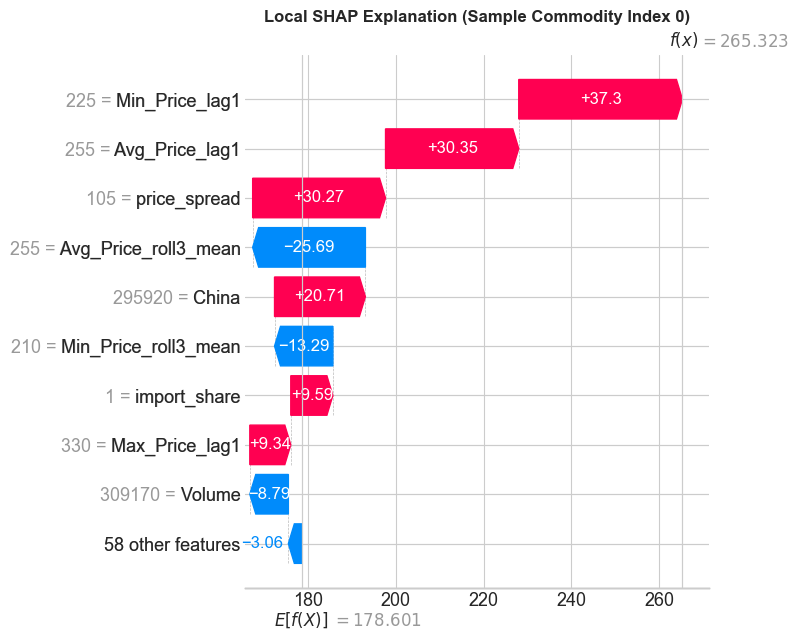

In [72]:
# Local Waterfall Plot for an Individual Out-of-Sample Item

sample_idx = 0  # Select first test sample commodity

plt.figure(figsize=(9, 6))
shap.plots.waterfall(shap_explanations['Avg_Price_next'][sample_idx], max_display=10, show=False)
plt.title(f"Local SHAP Explanation (Sample Commodity Index {sample_idx})", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [73]:
# Export Test Set Predictions (Months 9 & 10)

results_test_df = df_clean.loc[test_mask, ['Product_Name', 'month_idx']].copy().reset_index(drop=True)

for i, col in enumerate(targets_next):
    results_test_df[f'Actual_{col}'] = y_test.iloc[:, i].values
    results_test_df[f'Predicted_{col}'] = np.round(y_pred[:, i], 2)
    results_test_df[f'Baseline_{col}'] = y_baseline[:, i]

output_test_path = os.path.join('data', 'Testing_lightgbm_forecast_results.csv')
results_test_df.to_csv(output_test_path, index=False)
print(f"✓ Testing forecast results saved to '{output_test_path}'")

✓ Testing forecast results saved to 'data/Testing_lightgbm_forecast_results.csv'


In [75]:
# Export All Months Predictions (Full Dataset X)

y_pred_all_arr = model.predict(X)
y_pred_all_df = pd.DataFrame(y_pred_all_arr, columns=targets_next)

# Apply business logic constraints across all predictions
y_pred_all_df['Min_Price_next'] = np.minimum(y_pred_all_df['Min_Price_next'], y_pred_all_df['Avg_Price_next'])
y_pred_all_df['Max_Price_next'] = np.maximum(y_pred_all_df['Max_Price_next'], y_pred_all_df['Avg_Price_next'])

results_all_df = df_clean[['Product_Name', 'month_idx']].copy().reset_index(drop=True)

for col in targets_next:
    results_all_df[f'Actual_{col}'] = y[col].values
    results_all_df[f'Predicted_{col}'] = np.round(y_pred_all_df[col].values, 2)

output_all_path = os.path.join('data', 'Lightgbm_forecast_results_all_months.csv')
results_all_df.to_csv(output_all_path, index=False)
print(f"✓ Complete all-months forecast results saved to '{output_all_path}'")

print("\nSample Forecast Output (All Months):")
print(results_all_df.head())

✓ Complete all-months forecast results saved to 'data/Lightgbm_forecast_results_all_months.csv'

Sample Forecast Output (All Months):
     Product_Name  month_idx  Actual_Min_Price_next  Predicted_Min_Price_next  \
0  Akabary_Chilly          1                  300.0                    280.96   
1  Akabary_Chilly          2                  300.0                    361.44   
2  Akabary_Chilly          3                  300.0                    339.77   
3  Akabary_Chilly          4                  400.0                    390.47   
4           Amala          1                  100.0                     68.85   

   Actual_Avg_Price_next  Predicted_Avg_Price_next  Actual_Max_Price_next  \
0                 628.57                    429.28                  900.0   
1                 555.56                    603.60                  800.0   
2                 439.77                    612.57                  500.0   
3                 450.00                    612.30                  500